In [ ]:
!pip install -q tiktoken google-generativeai transformers datasets pandas matplotlib seaborn


In [ ]:
!pip install -q google-genai

Saving flores200_dev.tsv to flores200_dev.tsv


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (44273 > 2048). Running this sequence through the model will result in indexing errors


=== TOKENIZER TAX (LÍNEA BASE: ENGLISH = 1.0) ===
Language  GPT-5 (Tax)  Gemini (Tax)  Llama-2 (Tax)
 Spanish     1.546941      1.280229       1.440100
 English     1.000000      1.000000       1.000000
  French     1.583944      1.369708       1.444556
  German     1.574799      1.302887       1.402466
  Arabic     3.031036      1.451112       3.293075
 Chinese     1.891859      1.089888       1.936864
 Russian     2.496377      1.369038       1.635462
   Hindi     4.804913      1.305008       4.426861
 Swahili     1.950870      1.608713       1.823992
 Guarani     2.177109      1.896681       1.953062


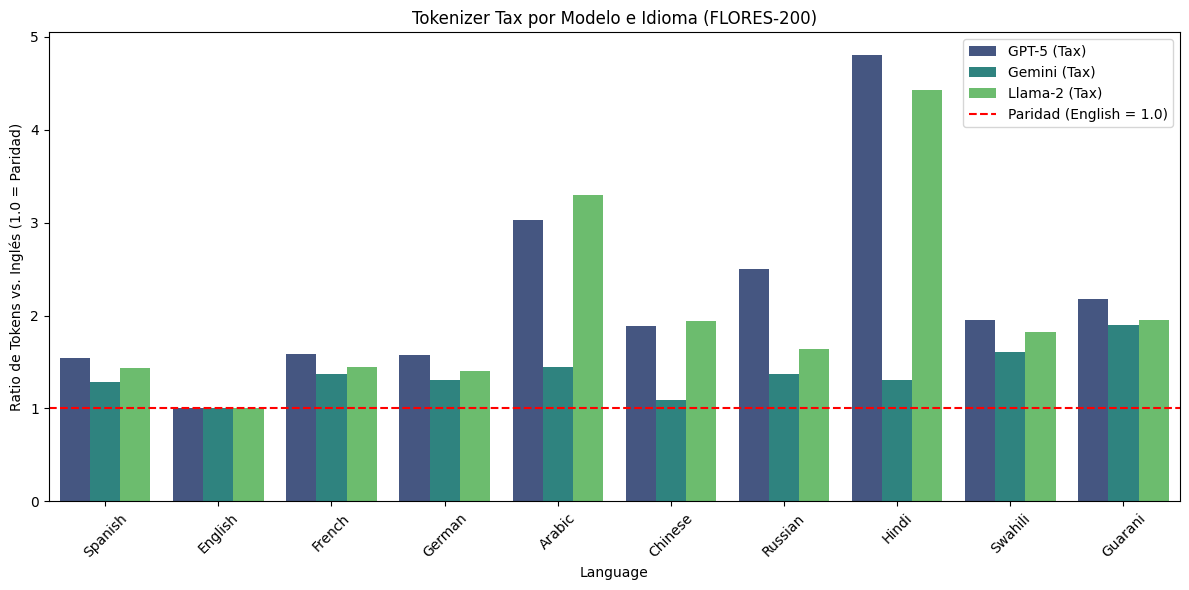


¡Proceso completado! Archivo 'tokenizer_tax_results.csv' listo.


In [ ]:
import os
import pandas as pd
import tiktoken
import google.generativeai as genai
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
os.environ["GEMINI_API_KEY"] = userdata.get('GEMINI_API_KEY')

enc_gpt = tiktoken.get_encoding("cl100k_base")

genai.configure(api_key=os.environ["GEMINI_API_KEY"])
model_gemini = genai.GenerativeModel('gemini-3.6-flash')

tokenizer_llama = AutoTokenizer.from_pretrained("huggyllama/llama-7b")
from google.colab import files
uploaded = files.upload()

df_flores = pd.read_csv('flores200_dev.tsv', sep='\t')

languages = {
    'Spanish': 'spa_Latn.dev',
    'English': 'eng_Latn.dev',
    'French': 'fra_Latn.dev',
    'German': 'deu_Latn.dev',
    'Arabic': 'arb_Arab.dev',
    'Chinese': 'zho_Hans.dev',
    'Russian': 'rus_Cyrl.dev',
    'Hindi': 'hin_Deva.dev',
    'Swahili': 'swh_Latn.dev',
    'Guarani': 'grn_Latn.dev'
}

raw_token_counts = []

for lang_name, file_key in languages.items():
    sub_df = df_flores[df_flores['file'] == file_key]

    if sub_df.empty:
        sub_df = df_flores[df_flores['file'].astype(str).str.contains(file_key.split('.')[0], case=False, na=False)]

    sample_texts = sub_df['text'].dropna().astype(str).tolist()[:50]

    if not sample_texts:
        continue

    tokens_gpt = sum(len(enc_gpt.encode(text)) for text in sample_texts)
    tokens_gemini = sum(model_gemini.count_tokens(text).total_tokens for text in sample_texts)
    tokens_llama = sum(len(tokenizer_llama.encode(text)) for text in sample_texts)

    raw_token_counts.append({
        'Language': lang_name,
        'GPT-5': tokens_gpt,
        'Gemini': tokens_gemini,
        'Llama-2': tokens_llama
    })

df_raw = pd.DataFrame(raw_token_counts)

base_en = df_raw[df_raw['Language'] == 'English'].iloc[0]

tax_results = []
for _, row in df_raw.iterrows():
    tax_results.append({
        'Language': row['Language'],
        'GPT-5 (Tax)': row['GPT-5'] / base_en['GPT-5'],
        'Gemini (Tax)': row['Gemini'] / base_en['Gemini'],
        'Llama-2 (Tax)': row['Llama-2'] / base_en['Llama-2']
    })

df_tax = pd.DataFrame(tax_results)

print("=== TOKENIZER TAX (LÍNEA BASE: ENGLISH = 1.0) ===")
print(df_tax.to_string(index=False))

df_melted_tax = df_tax.melt(
    id_vars=['Language'],
    var_name='Model',
    value_name='Tokenizer Tax (x English tokens)'
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_melted_tax,
    x='Language',
    y='Tokenizer Tax (x English tokens)',
    hue='Model',
    palette='viridis'
)

plt.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Paridad (English = 1.0)')
plt.title('Tokenizer Tax por Modelo e Idioma (FLORES-200)')
plt.ylabel('Ratio de Tokens vs. Inglés (1.0 = Paridad)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

df_tax.to_csv('tokenizer_tax_results.csv', index=False)
print("\n¡Proceso completado! Archivo 'tokenizer_tax_results.csv' listo.")

Textos por idioma encontrados: {'Spanish': 1, 'English': 1, 'French': 1, 'German': 1, 'Arabic': 1, 'Chinese': 1, 'Russian': 1, 'Hindi': 1, 'Swahili': 1, 'Guarani': 1}
Muestras comunes a evaluar (min_len): 1


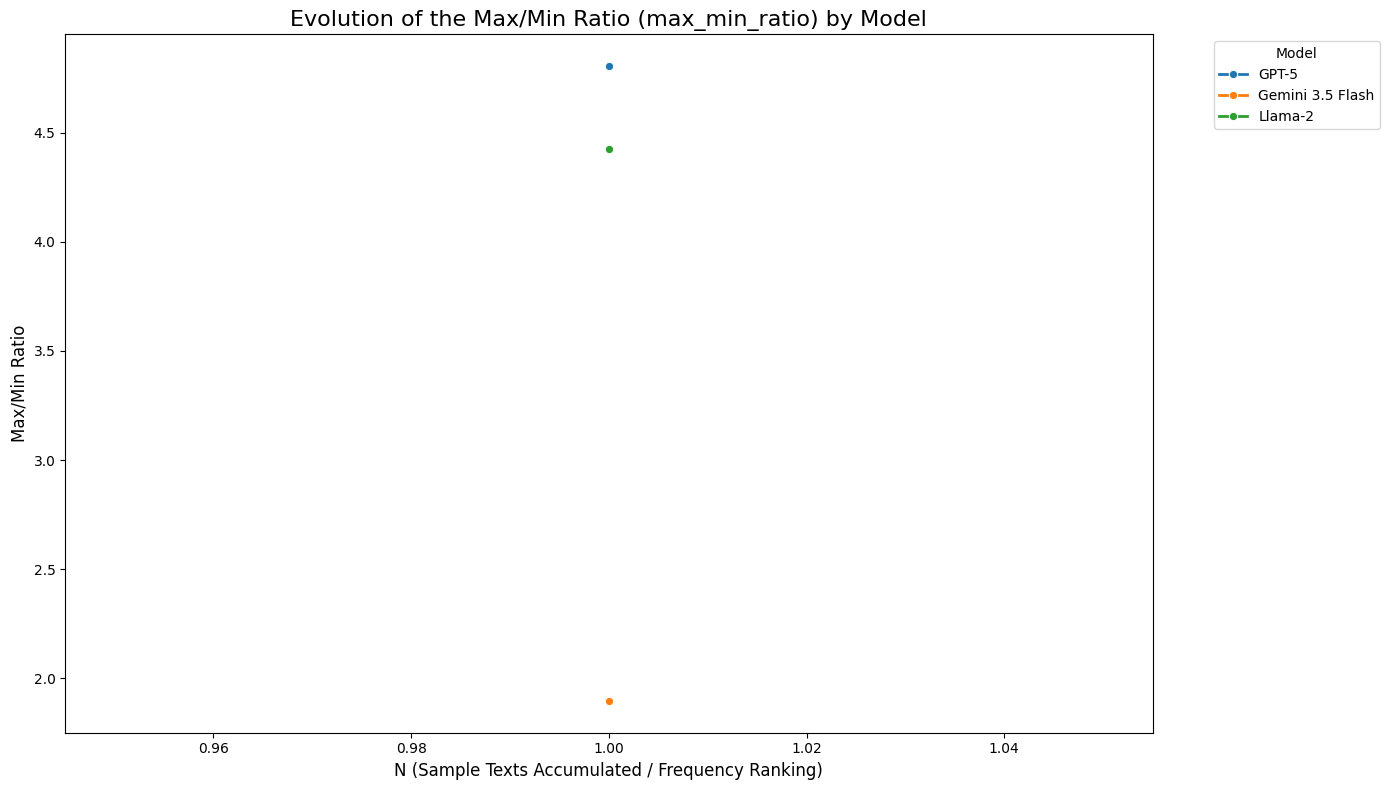

In [ ]:

texts_by_lang = {}
for lang_name, file_key in languages.items():
    sub_df = df_flores[df_flores['file'] == file_key]
    if sub_df.empty:
        sub_df = df_flores[df_flores['file'].astype(str).str.contains(file_key.split('.')[0], case=False, na=False)]

    samples = sub_df['text'].dropna().astype(str).tolist()[:50]
    if len(samples) > 0:
        texts_by_lang[lang_name] = samples

lengths = [len(t) for t in texts_by_lang.values()]
print(f"Textos por idioma encontrados: { {k: len(v) for k, v in texts_by_lang.items()} }")

min_len = min(lengths)
print(f"Muestras comunes a evaluar (min_len): {min_len}")

models = {
    'GPT-5': lambda t: len(enc_gpt.encode(t)),
    'Gemini 3.5 Flash': lambda t: model_gemini.count_tokens(t).total_tokens,
    'Llama-2': lambda t: len(tokenizer_llama.encode(t))
}

token_matrix = {
    model: {lang: [func(t) for t in texts_by_lang[lang][:min_len]]
            for lang in texts_by_lang}
    for model, func in models.items()
}

records = []
for N in range(1, min_len + 1):
    for model_name in models.keys():
        lang_totals = [sum(token_matrix[model_name][lang][:N]) for lang in texts_by_lang.keys()]

        min_tokens = min(lang_totals)
        max_tokens = max(lang_totals)

        ratio = (max_tokens / min_tokens) if min_tokens > 0 else 1.0

        records.append({
            'N': N,
            'max_min_ratio': ratio,
            'model': model_name
        })

ratio_df = pd.DataFrame(records)

plt.figure(figsize=(14, 8))
# Agregamos marker='o' para que los puntos sean visibles incluso si hay pocos N
sns.lineplot(data=ratio_df, x='N', y='max_min_ratio', hue='model', linewidth=2, marker='o')

plt.title('Evolution of the Max/Min Ratio (max_min_ratio) by Model', fontsize=16)
plt.xlabel('N (Sample Texts Accumulated / Frequency Ranking)', fontsize=12)
plt.ylabel('Max/Min Ratio', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Model', fontsize=10)
plt.tight_layout()
plt.show()